In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
from astropy.table import Table
from astropy.io import ascii
import matplotlib.pyplot as plt
from scipy.spatial import Delaunay
import pandas as pd
from itertools import combinations
import networkx as nx
from sklearn.decomposition import PCA
import matplotlib.cm as cm
import itertools
from scipy.spatial import cKDTree

In [3]:
filt_n1 = Table.read("/content/drive/MyDrive/DESI/data/LRG_NGC_data_filt1.ecsv").to_pandas()

In [4]:
n_random = 10
rand_ngc1 = {}
for i in range(n_random):
    rand_ngc1[i] = Table.read(f"/content/drive/MyDrive/DESI/rand/LRG_NGC_1_random_{i}_filt.fits").to_pandas()
    rand_ngc1[i]['type'] = 'rand'

In [5]:
void = {}
for j in range(1):
        file = f"/content/drive/MyDrive/DESI/connections_groups/LRG_NGC_1_random_{j}_neighbors_void.parquet"
        df = pd.read_parquet(file)
        void[j] = df

In [6]:
filament = {}
for j in range(1):
        file = f"/content/drive/MyDrive/DESI/connections_groups/LRG_NGC_1_random_{j}_neighbors_filament.parquet"
        df = pd.read_parquet(file)
        filament[j] = df

In [7]:
knot = {}
for j in range(1):
        file = f"/content/drive/MyDrive/DESI/connections_groups/LRG_NGC_1_random_{j}_neighbors_knot.parquet"
        df = pd.read_parquet(file)
        knot[j] = df

In [8]:
def identify_fof_groups(data, group, linking_length=50):
    id_group = zip(group['TARGETID'],group['TARGETID_filament'])

    targetid_filaments = group['TARGETID_filament'].unique()
    data = data[data['TARGETID'].isin(targetid_filaments)].copy()

    #Aplicar Friends-of-Friends (FoF) con KDTree
    positions = data[['x', 'y', 'z']].values
    tree = cKDTree(positions)
    pairs = tree.query_pairs(r=linking_length)

    #Construir grupos (componentes conexas)
    parent = list(range(len(positions)))

    def find(i):
        while parent[i] != i:
            parent[i] = parent[parent[i]]
            i = parent[i]
        return i

    def union(i, j):
        ri, rj = find(i), find(j)
        if ri != rj:
            parent[ri] = rj

    for i, j in pairs:
        union(i, j)

    group_ids = np.array([find(i) for i in range(len(positions))])
    _, group_ids = np.unique(group_ids, return_inverse=True)
    data['group_id'] = group_ids

    return data

In [9]:
def plot_top_n_groups(df, n=3, point_size=0.01):

    # obtain the N groups with the most points
    top_ids = df['group_id'].value_counts().head(n).index.tolist()

    colors = plt.cm.tab20(np.linspace(0, 1, n))

    plt.figure(figsize=(12, 10))
    for group_id, color in zip(top_ids, colors):
        subset = df[df['group_id'] == group_id]
        plt.scatter(subset['x_rot'], subset['y_rot'], s=point_size, label=f'Group {group_id}')

    plt.xlabel("X [Mpc]", fontsize=14)
    plt.ylabel("Y [Mpc]", fontsize=14)
    plt.title(f"Top {n} Groups with Most Points - Filaments",fontsize=15)
    #plt.legend(fontsize=8)
    #plt.grid(True)
    plt.gca().set_aspect('equal', adjustable='box')
    plt.tight_layout()
    plt.gca().set_aspect('equal', adjustable='box')
    plt.show()

In [10]:
def alignment(df):
    if hasattr(df, 'to_pandas'):
        df = df.to_pandas()
    coords = df[['x', 'y', 'z']].values.astype(float)
    pca = PCA(n_components=3)
    coords_rotated = pca.fit_transform(coords)
    return coords_rotated

In [11]:
def new_coords(data):
    new_coords = alignment(data)
    data[['x_rot', 'y_rot', 'z_rot']] = new_coords

In [21]:
new_coords(filt_n1)
new_coords(rand_ngc1[0])

# DZ

## Linking_length = 20

In [42]:
%%time
df_filament_groups_d = identify_fof_groups(filt_n1, filament[0], linking_length=20)

CPU times: user 4.63 s, sys: 574 ms, total: 5.2 s
Wall time: 5.21 s


In [43]:
new_coords(df_filament_groups_d)

In [44]:
print('Number groups: ',len(set(df_filament_groups_d['group_id'])))

Number groups:  29287


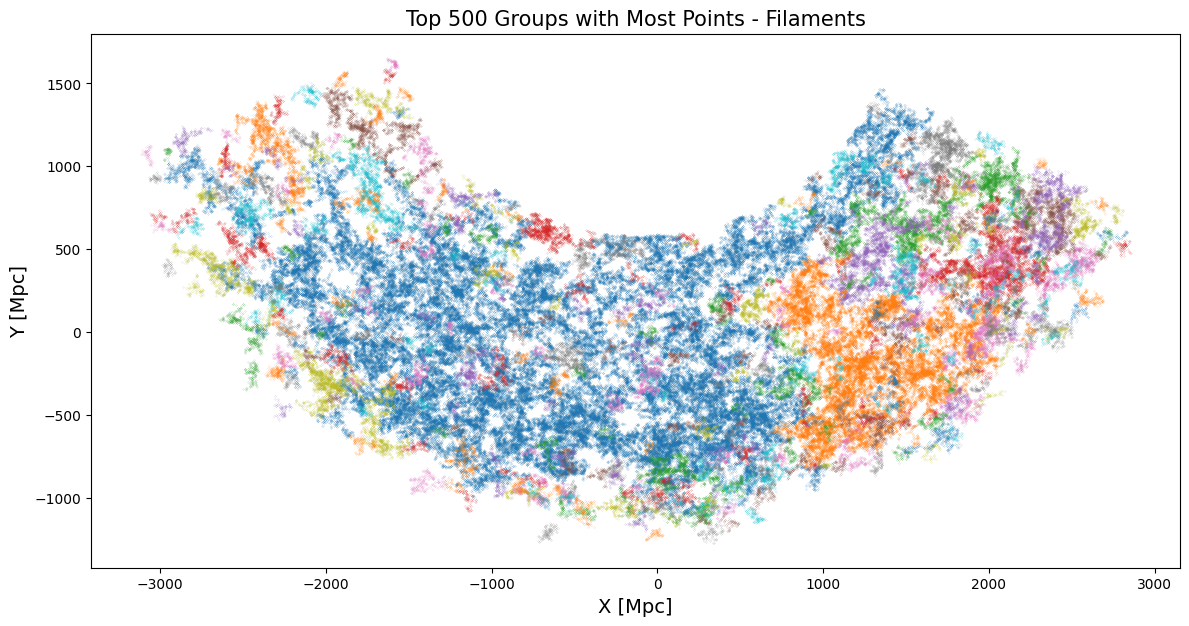

In [45]:
plot_top_n_groups(df_filament_groups_d, n=500)

# SGM

In [22]:
def network_max(data, group, string_group, max_neighbors=None, max_distance=None):
    filt_data = data[['TARGETID', 'x_rot', 'y_rot', 'z_rot']].copy()

    #merge coords
    group_coords = group.merge(filt_data, on='TARGETID', how='left') \
                        .rename(columns={'x_rot': 'x_src', 'y_rot': 'y_src', 'z_rot': 'z_src'})
    group_coords = group_coords.merge(
        filt_data,
        left_on=f'TARGETID_{string_group}',
        right_on='TARGETID',
        how='left',
        suffixes=('', '_dst')
    ).rename(columns={'x_rot': 'x_dst', 'y_rot': 'y_dst', 'z_rot': 'z_dst'})

    #distance
    group_coords['dist'] = np.sqrt(
        (group_coords['x_src'] - group_coords['x_dst'])**2 +
        (group_coords['y_src'] - group_coords['y_dst'])**2 +
        (group_coords['z_src'] - group_coords['z_dst'])**2
    )

    #max_distance
    if max_distance is not None:
        group_coords = group_coords[group_coords['dist'] <= max_distance]

    #max_neighbors
    if max_neighbors is not None:
        group_coords = (group_coords
                        .sort_values(['TARGETID', 'dist'])
                        .groupby('TARGETID', group_keys=False)
                        .head(max_neighbors))
    G = nx.Graph()
    G.add_edges_from(zip(group_coords['TARGETID'], group_coords[f'TARGETID_{string_group}']))

    componentes = list(nx.connected_components(G))
    print(f"Components: {len(componentes)} with max_neighbors={max_neighbors}, max_distance={max_distance}")

    df_grupo_new = {}
    for comp in componentes:
        ids = list(comp)
        gid = ids[0]
        df = filt_data[filt_data['TARGETID'].isin(ids)].copy()
        df['id'] = gid
        df_grupo_new[gid] = df

    return df_grupo_new, G

In [26]:
def groups(data,G):
  data_indexed = data.set_index('TARGETID')

  groups = {}

  componentes = list(nx.connected_components(G))

  print(f"Groups: {len(componentes)}")

  for i, comp in enumerate(componentes, start=1):

      ids_en_grupo = [node for node in comp if node in data_indexed.index]
      if len(ids_en_grupo) == 0:
          continue
      df_grupo = data_indexed.loc[ids_en_grupo].copy().reset_index()
      groups[i] = df_grupo
  return groups

In [30]:
def plot_top_groups(groups, title, top_n=10):
    sorted_groups = sorted(groups.items(), key=lambda item: len(item[1]), reverse=True)
    top_groups = sorted_groups[:top_n]

    fig, ax = plt.subplots(figsize=(12, 10))
    colors = itertools.cycle(plt.cm.tab10.colors)

    for group_id, df_grupo in top_groups:
        ax.scatter(
            df_grupo['x_rot'],
            df_grupo['y_rot'],
            s=6,
            color=next(colors),
            label=f'Grupo {group_id} (n={len(df_grupo)})'
        )

    ax.set_xlabel('PC1', fontsize=14)
    ax.set_ylabel('PC2', fontsize=14)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, linestyle='--', linewidth=0.5)
    ax.set_title(f'Top {top_n} bigger sizes - {title}', fontsize=15)
    ax.legend(markerscale=2, fontsize=8, loc='upper right', ncol=2)
    plt.tight_layout()
    plt.show()

In [24]:
%%time
group_filament_max, G_filament_max = network_max(
    data=filt_n1,
    group=filament[0],
    string_group='filament',
    max_neighbors=20,
    max_distance=21
)

Components: 14558 with max_neighbors=20, max_distance=21
CPU times: user 3min 58s, sys: 1.3 s, total: 3min 59s
Wall time: 4min 13s


In [27]:
final_group_filament_max = groups(filt_n1,G_filament_max)

Groups: 14558


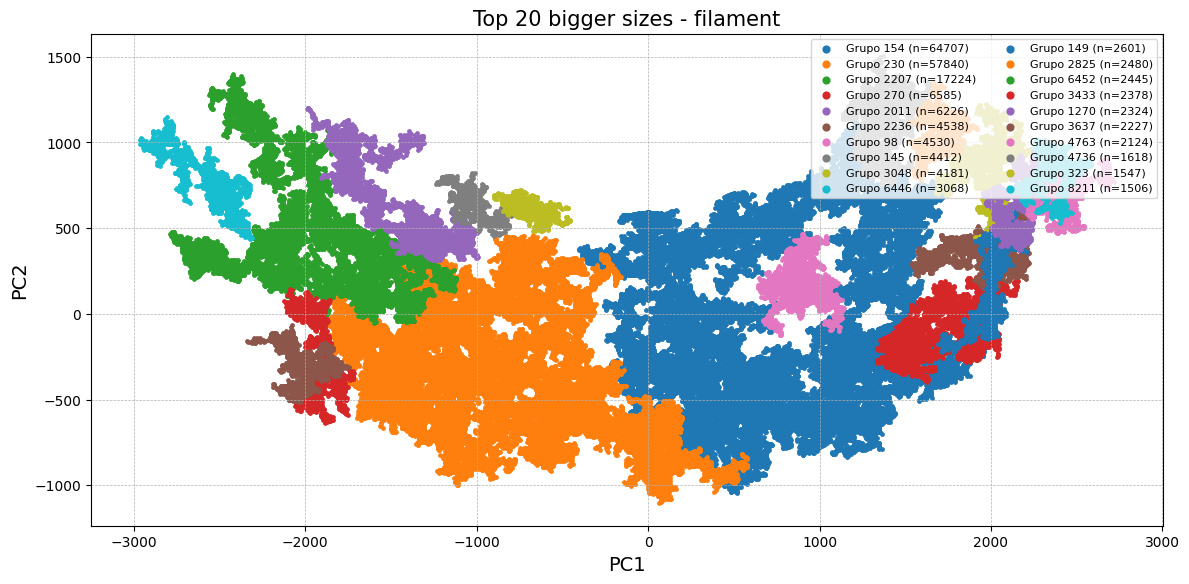

In [32]:
plot_top_groups(final_group_filament_max,'filament',top_n=20)

# Comparison

In [52]:
def size_top_s(groups,top_n=20):
  sorted_groups = sorted(groups.items(), key=lambda item: len(item[1]), reverse=True)
  top_groups = sorted_groups[:top_n]
  sizes = list()
  for group_id, df_group in top_groups:
      sizes.append(len(df_group))
  return sizes

In [86]:
def size_top_d(df_groups, top_n=20):
    group_sizes = df_groups.groupby('group_id').size()
    top_group_ids = group_sizes.sort_values(ascending=False).head(top_n).index
    sizes=list()
    for group_id in top_group_ids:
        sizes.append(int(group_sizes[group_id]))

    return sizes

In [88]:
filaments_s = size_top_s(final_group_filament_max,top_n=1000)
filaments_d = size_top_d(df_filament_groups_d,top_n=1000)
filaments_slog = np.log10(filaments_s)
filaments_dlog = np.log10(filaments_d)

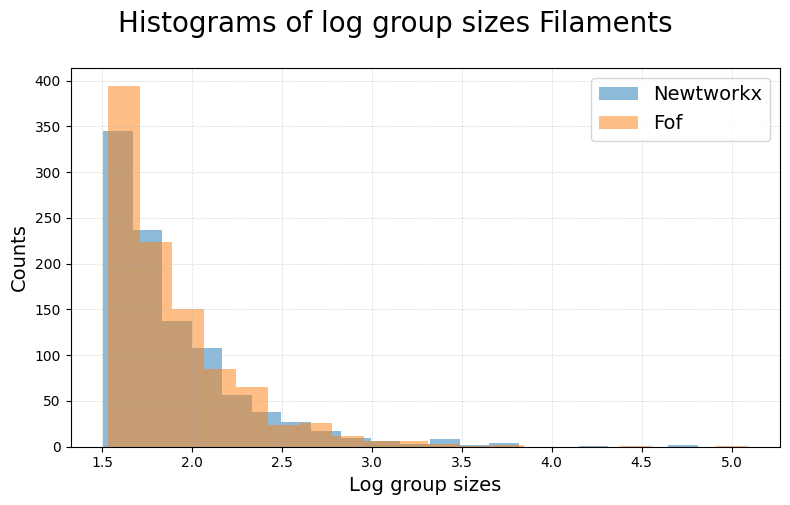

In [96]:
fig, ax = plt.subplots(figsize=(8, 5))

title = 'Filaments'

ax.hist(filaments_slog, bins=20, alpha=0.5,label='Newtworkx')
ax.hist(filaments_dlog, bins=20, alpha=0.5,label = 'Fof')

ax.set_xlabel('Log group sizes',fontsize=14)
ax.set_ylabel('Counts',fontsize=14)
ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)

fig.suptitle(f'Histograms of log group sizes {title}', fontsize=20, y=1)

plt.tight_layout()
plt.legend(fontsize=14)
plt.show()